In [ ]:
!pip install pandas numpy scikit-learn tqdm matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from urllib.parse import urlparse
from tqdm import tqdm
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==========================================
# Upload CSV, Load, Check Shape & Columns
# ==========================================

import pandas as pd
from google.colab import files

# Step 1: Upload file
uploaded = files.upload()

# Step 2: Automatically get file name
file_name = list(uploaded.keys())[0]

# Step 3: Read CSV
df = pd.read_csv(file_name)

# Step 4: Print shape
print("Dataset Shape:", df.shape)

# Step 5: Print number of columns
print("Number of Columns:", len(df.columns))

# Step 6: Print column names
print("Column Names:")
print(df.columns.tolist())


Saving CEAS_08.csv to CEAS_08.csv
Dataset Shape: (39154, 7)
Number of Columns: 7
Column Names:
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']


In [ ]:
df = pd.read_csv('CEAS_08.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (39154, 7)

Column names: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

First few rows:


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
print("Label Distribution:")
print(df['label'].value_counts())
print(f"\nUnique labels: {df['label'].unique()}")

Label Distribution:
label
1    21842
0    17312
Name: count, dtype: int64

Unique labels: [1 0]


In [ ]:
TOTAL_SAMPLES = 10000
labels = df['label'].unique()
samples_per_class = TOTAL_SAMPLES // len(labels)

print(f"Total samples needed: {TOTAL_SAMPLES}")
print(f"Samples per class: {samples_per_class}")
print(f"Number of classes: {len(labels)}")

balanced_dfs = []
for label in labels:
    label_df = df[df['label'] == label]
    print(f"\nLabel '{label}': {len(label_df)} samples available")

    if len(label_df) >= samples_per_class:
        sampled = label_df.sample(n=samples_per_class, random_state=42)
        print(f"  -> Downsampled to {samples_per_class}")
    else:
        sampled = resample(label_df, n_samples=samples_per_class, random_state=42, replace=True)
        print(f"  -> Upsampled to {samples_per_class}")

    balanced_dfs.append(sampled)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*40}")
print(f"Balanced dataset shape: {df_balanced.shape}")
print(f"\nBalanced label distribution:")
print(df_balanced['label'].value_counts())

Total samples needed: 10000
Samples per class: 5000
Number of classes: 2

Label '1': 21842 samples available
  -> Downsampled to 5000

Label '0': 17312 samples available
  -> Downsampled to 5000

Balanced dataset shape: (10000, 7)

Balanced label distribution:
label
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
URGENCY_WORDS = [
    'urgent', 'immediate', 'act now', 'action required', 'expire', 'expires',
    'limited time', 'hurry', 'fast', 'quick', 'asap', 'deadline', 'alert',
    'warning', 'important', 'attention', 'priority', 'instantly', 'now'
]

FINANCIAL_WORDS = [
    'bank', 'account', 'verify', 'password', 'credit', 'debit', 'paypal',
    'transfer', 'payment', 'invoice', 'transaction', 'balance', 'fund',
    'money', 'dollar', 'bitcoin', 'wallet', 'ssn', 'social security', 'tax',
    'refund', 'lottery', 'winner', 'prize', 'reward', 'bonus', 'free'
]

THREAT_WORDS = [
    'suspended', 'locked', 'unauthorized', 'blocked', 'disabled', 'closed',
    'terminate', 'restrict', 'compromise', 'breach', 'fraud', 'illegal',
    'violation', 'security', 'risk', 'dangerous', 'threat', 'stolen'
]

ACTION_WORDS = [
    'click', 'login', 'log in', 'sign in', 'update', 'confirm', 'verify',
    'validate', 'submit', 'enter', 'provide', 'download', 'install', 'open'
]

print("Keyword lists defined!")
print(f"Urgency words: {len(URGENCY_WORDS)}")
print(f"Financial words: {len(FINANCIAL_WORDS)}")
print(f"Threat words: {len(THREAT_WORDS)}")
print(f"Action words: {len(ACTION_WORDS)}")

Keyword lists defined!
Urgency words: 19
Financial words: 27
Threat words: 18
Action words: 14


In [ ]:
def extract_header_features(row):
    features = {}
    sender = str(row['sender']) if pd.notna(row['sender']) else ''
    receiver = str(row['receiver']) if pd.notna(row['receiver']) else ''

    # Extract sender domain
    sender_domain = ''
    sender_match = re.search(r'@([\w.-]+)', sender)
    if sender_match:
        sender_domain = sender_match.group(1).lower()

    # Extract receiver domain
    receiver_domain = ''
    receiver_match = re.search(r'@([\w.-]+)', receiver)
    if receiver_match:
        receiver_domain = receiver_match.group(1).lower()

    # Header features
    features['sender_has_name'] = 1 if '<' in sender else 0
    features['sender_domain_length'] = len(sender_domain)
    features['sender_has_numbers'] = 1 if re.search(r'\d', sender) else 0
    features['sender_has_suspicious_tld'] = 1 if any(
        sender_domain.endswith(tld) for tld in ['.xyz', '.tk', '.pw', '.cc', '.ru', '.cn', '.info', '.biz']
    ) else 0
    features['sender_receiver_same_domain'] = 1 if sender_domain == receiver_domain and sender_domain != '' else 0

    # Check name-email mismatch
    features['sender_name_email_mismatch'] = 0
    if '<' in sender:
        name_part = sender.split('<')[0].lower().strip()
        email_part = sender.split('<')[1].replace('>', '').lower()
        local_part = email_part.split('@')[0] if '@' in email_part else ''
        if name_part and local_part:
            features['sender_name_email_mismatch'] = 0 if any(n in local_part for n in name_part.split()) else 1

    features['multiple_receivers'] = 1 if ',' in receiver or ';' in receiver else 0
    features['sender_length'] = len(sender)

    return features

print("Header feature extraction function defined!")


Header feature extraction function defined!


In [ ]:
def extract_subject_features(subject):
    features = {}
    subject = str(subject) if pd.notna(subject) else ''
    subject_lower = subject.lower()

    # Basic stats
    features['subject_length'] = len(subject)
    features['subject_word_count'] = len(subject.split())

    # Reply/Forward indicators
    features['subject_has_re'] = 1 if subject_lower.startswith('re:') or ' re:' in subject_lower else 0
    features['subject_has_fw'] = 1 if subject_lower.startswith(('fw:', 'fwd:')) or ' fw:' in subject_lower else 0

    # Capitalization
    features['subject_all_caps'] = 1 if subject.isupper() and len(subject) > 3 else 0
    features['subject_caps_ratio'] = sum(1 for c in subject if c.isupper()) / max(len(subject), 1)

    # Punctuation
    features['subject_has_exclamation'] = 1 if '!' in subject else 0
    features['subject_exclamation_count'] = subject.count('!')
    features['subject_has_question'] = 1 if '?' in subject else 0
    features['subject_special_char_count'] = len(re.findall(r'[!@#$%^&*()_+=\[\]{};:"|<>?]', subject))
    features['subject_digit_count'] = sum(c.isdigit() for c in subject)

    # Keyword flags
    features['subject_has_urgency'] = 1 if any(word in subject_lower for word in URGENCY_WORDS) else 0
    features['subject_has_financial'] = 1 if any(word in subject_lower for word in FINANCIAL_WORDS) else 0
    features['subject_has_threat'] = 1 if any(word in subject_lower for word in THREAT_WORDS) else 0
    features['subject_has_action'] = 1 if any(word in subject_lower for word in ACTION_WORDS) else 0

    return features

print("Subject feature extraction function defined!")

Subject feature extraction function defined!


In [ ]:
def extract_body_features(body):
    features = {}
    body = str(body) if pd.notna(body) else ''
    body_lower = body.lower()

    # Basic text stats
    features['body_length'] = len(body)
    words = body.split()
    features['body_word_count'] = len(words)
    features['body_avg_word_length'] = np.mean([len(w) for w in words]) if words else 0
    features['body_sentence_count'] = len(re.findall(r'[.!?]+', body))

    # Character ratios
    features['body_caps_ratio'] = sum(1 for c in body if c.isupper()) / max(len(body), 1)
    features['body_digit_ratio'] = sum(1 for c in body if c.isdigit()) / max(len(body), 1)
    features['body_special_char_ratio'] = len(re.findall(r'[!@#$%^&*()_+=\[\]{};:"|<>?]', body)) / max(len(body), 1)
    features['body_whitespace_ratio'] = sum(1 for c in body if c.isspace()) / max(len(body), 1)

    # Punctuation counts
    features['body_exclamation_count'] = body.count('!')
    features['body_question_count'] = body.count('?')
    features['body_dollar_sign_count'] = body.count('$')

    # HTML indicators
    features['body_has_html'] = 1 if re.search(r'<[^>]+>', body) else 0
    features['body_html_tag_count'] = len(re.findall(r'<[^>]+>', body))
    features['body_has_href'] = 1 if 'href=' in body_lower else 0
    features['body_has_form'] = 1 if '<form' in body_lower else 0
    features['body_has_input'] = 1 if '<input' in body_lower else 0
    features['body_has_script'] = 1 if '<script' in body_lower else 0

    # URL features
    urls = re.findall(r'https?://[^\s<>"\']+', body)
    features['body_url_count'] = len(urls)
    features['body_has_ip_url'] = 1 if re.search(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', body) else 0
    features['body_has_shortened_url'] = 1 if any(
        short in body_lower for short in ['bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly', 'is.gd', 'buff.ly']
    ) else 0

    # Keyword counts
    features['body_urgency_count'] = sum(1 for word in URGENCY_WORDS if word in body_lower)
    features['body_financial_count'] = sum(1 for word in FINANCIAL_WORDS if word in body_lower)
    features['body_threat_count'] = sum(1 for word in THREAT_WORDS if word in body_lower)
    features['body_action_count'] = sum(1 for word in ACTION_WORDS if word in body_lower)

    # Keyword flags
    features['body_has_urgency'] = 1 if features['body_urgency_count'] > 0 else 0
    features['body_has_financial'] = 1 if features['body_financial_count'] > 0 else 0
    features['body_has_threat'] = 1 if features['body_threat_count'] > 0 else 0
    features['body_has_action'] = 1 if features['body_action_count'] > 0 else 0

    # Personal info requests
    features['body_asks_personal_info'] = 1 if any(
        term in body_lower for term in ['social security', 'ssn', 'credit card', 'password', 'pin number', 'date of birth', "mother's maiden"]
    ) else 0

    # Greeting patterns
    features['body_has_generic_greeting'] = 1 if any(
        g in body_lower for g in ['dear customer', 'dear user', 'dear member', 'dear client', 'valued customer', 'dear account holder']
    ) else 0
    features['body_has_personalized_greeting'] = 1 if re.search(r'dear [a-z]+[,\s]', body_lower) else 0

    # Grammar indicators
    features['body_has_multiple_spaces'] = 1 if '  ' in body else 0
    features['body_missing_space_count'] = len(re.findall(r'[a-z][A-Z]', body))

    return features

print("Body feature extraction function defined!")

Body feature extraction function defined!


In [ ]:
print("Starting feature extraction...")
print(f"Processing {len(df_balanced)} emails\n")

all_features = []

for idx, row in tqdm(df_balanced.iterrows(), total=len(df_balanced), desc="Extracting features"):
    features = {}

    # Extract header features
    header_feats = extract_header_features(row)
    features.update(header_feats)

    # Extract subject features
    subject_feats = extract_subject_features(row['subject'])
    features.update(subject_feats)

    # Extract body features
    body_feats = extract_body_features(row['body'])
    features.update(body_feats)

    # Add label
    features['label'] = row['label']

    all_features.append(features)

# Create features dataframe
df_features = pd.DataFrame(all_features)

print(f"\n{'='*40}")
print(f"Feature extraction complete!")
print(f"Shape: {df_features.shape}")

Starting feature extraction...
Processing 10000 emails



Extracting features: 100%|██████████| 10000/10000 [00:08<00:00, 1242.56it/s]



Feature extraction complete!
Shape: (10000, 57)


In [ ]:
print(f"Total features extracted: {len(df_features.columns) - 1}")
print(f"\nFeature columns:")
for i, col in enumerate(df_features.columns):
    print(f"  {i+1}. {col}")


Total features extracted: 56

Feature columns:
  1. sender_has_name
  2. sender_domain_length
  3. sender_has_numbers
  4. sender_has_suspicious_tld
  5. sender_receiver_same_domain
  6. sender_name_email_mismatch
  7. multiple_receivers
  8. sender_length
  9. subject_length
  10. subject_word_count
  11. subject_has_re
  12. subject_has_fw
  13. subject_all_caps
  14. subject_caps_ratio
  15. subject_has_exclamation
  16. subject_exclamation_count
  17. subject_has_question
  18. subject_special_char_count
  19. subject_digit_count
  20. subject_has_urgency
  21. subject_has_financial
  22. subject_has_threat
  23. subject_has_action
  24. body_length
  25. body_word_count
  26. body_avg_word_length
  27. body_sentence_count
  28. body_caps_ratio
  29. body_digit_ratio
  30. body_special_char_ratio
  31. body_whitespace_ratio
  32. body_exclamation_count
  33. body_question_count
  34. body_dollar_sign_count
  35. body_has_html
  36. body_html_tag_count
  37. body_has_href
  38. body

In [ ]:
X = df_features.drop('label', axis=1)
y = df_features['label']

print("Feature Statistics Summary:")
print("="*50)
X.describe().T

Feature Statistics Summary:


,count,mean,std,min,25%,50%,75%,max
sender_has_name,10000.0,0.928300,0.258003,0.0000,1.000000,1.000000,1.000000,1.000000
sender_domain_length,10000.0,12.479500,4.705400,0.0000,9.000000,12.000000,15.000000,46.000000
sender_has_numbers,10000.0,0.191400,0.393423,0.0000,0.000000,0.000000,0.000000,1.000000
sender_has_suspicious_tld,10000.0,0.014600,0.119951,0.0000,0.000000,0.000000,0.000000,1.000000
sender_receiver_same_domain,10000.0,0.037600,0.190236,0.0000,0.000000,0.000000,0.000000,1.000000
sender_name_email_mismatch,10000.0,0.825600,0.379472,0.0000,1.000000,1.000000,1.000000,1.000000
multiple_receivers,10000.0,0.054000,0.226029,0.0000,0.000000,0.000000,0.000000,1.000000
sender_length,10000.0,38.544800,10.395499,2.0000,33.000000,38.000000,44.000000,109.000000
subject_length,10000.0,39.743200,21.582892,0.0000,25.000000,36.000000,51.000000,285.000000
subject_word_count,10000.0,6.130200,3.260109,0.0000,4.000000,5.000000,8.000000,52.000000


In [ ]:
null_counts = X.isnull().sum()
null_features = null_counts[null_counts > 0]

if len(null_features) > 0:
    print("Features with missing values:")
    print(null_features)
else:
    print("✓ No missing values found in any features!")

print(f"\nDataset info:")
print(f"  - Samples: {X.shape[0]}")
print(f"  - Features: {X.shape[1]}")
print(f"  - Labels: {y.nunique()} classes")

✓ No missing values found in any features!

Dataset info:
  - Samples: 10000
  - Features: 56
  - Labels: 2 classes


In [ ]:
# Convert labels to numeric for correlation
df_features_numeric = df_features.copy()
label_mapping = {label: idx for idx, label in enumerate(df_features_numeric['label'].unique())}
df_features_numeric['label_numeric'] = df_features_numeric['label'].map(label_mapping)

print("Label mapping:", label_mapping)

# Calculate correlations
correlations = df_features_numeric.drop('label', axis=1).corr()['label_numeric'].drop('label_numeric')
correlations = correlations.sort_values(key=abs, ascending=False)

print("\nTop 20 Features Most Correlated with Label:")
print("="*50)
for feat, corr in correlations.head(20).items():
    print(f"  {feat}: {corr:.4f}")

Label mapping: {np.int64(0): 0, np.int64(1): 1}

Top 20 Features Most Correlated with Label:
  subject_special_char_count: -0.6317
  subject_has_re: -0.5727
  body_has_multiple_spaces: -0.4242
  subject_length: -0.3788
  body_special_char_ratio: -0.3323
  body_urgency_count: -0.2995
  subject_word_count: -0.2806
  subject_has_action: -0.2746
  sender_has_numbers: 0.2710
  body_has_urgency: -0.2579
  body_word_count: -0.2553
  body_action_count: -0.2339
  body_length: -0.2187
  subject_digit_count: -0.2078
  body_has_action: -0.1900
  sender_receiver_same_domain: -0.1840
  sender_has_name: 0.1826
  body_financial_count: -0.1816
  sender_length: 0.1764
  body_caps_ratio: 0.1645


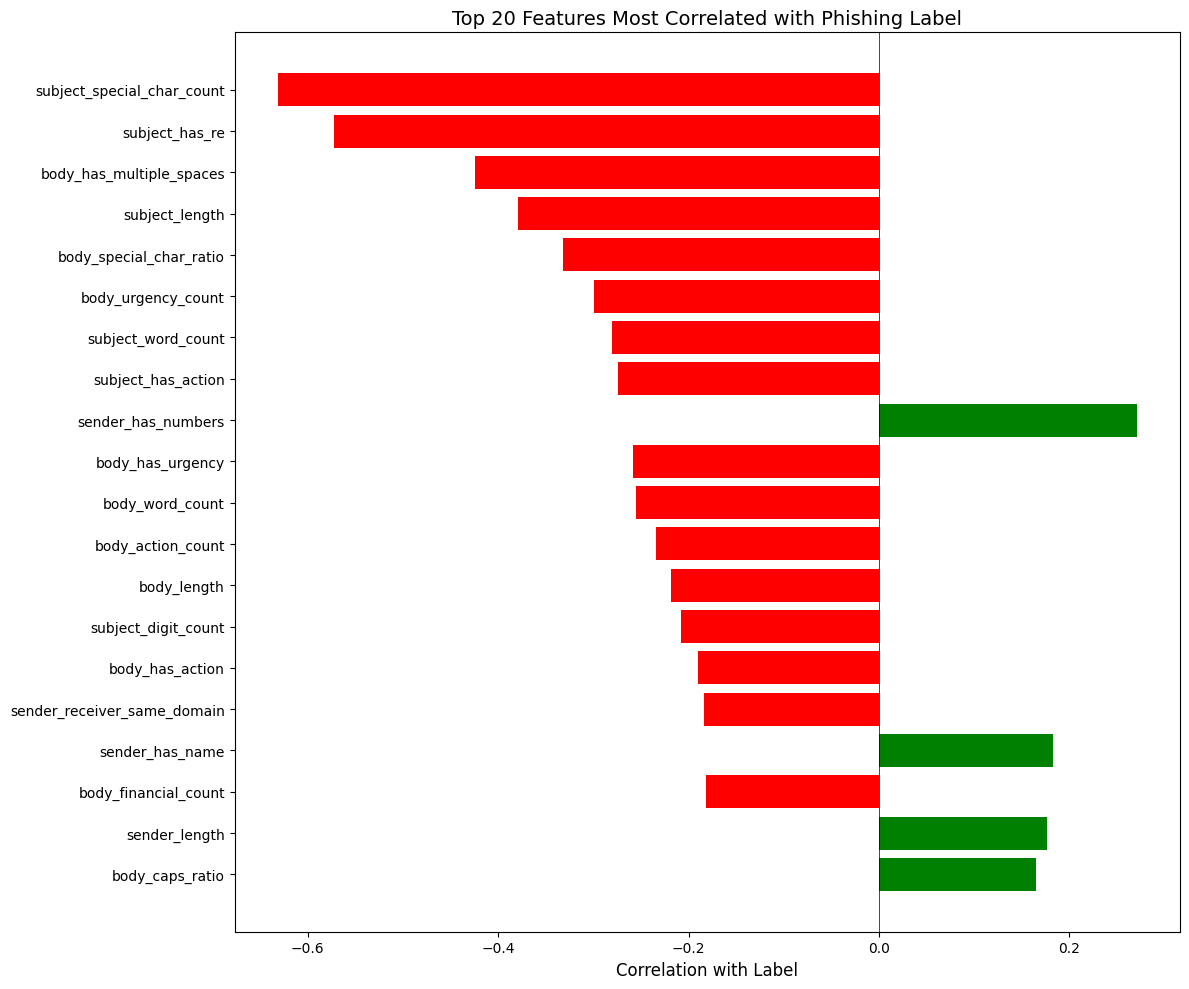


Plot saved as 'feature_correlations.png'


In [ ]:
plt.figure(figsize=(12, 10))
top_20_corr = correlations.head(20)

colors = ['green' if x > 0 else 'red' for x in top_20_corr.values]
bars = plt.barh(range(len(top_20_corr)), top_20_corr.values, color=colors)

plt.yticks(range(len(top_20_corr)), top_20_corr.index)
plt.xlabel('Correlation with Label', fontsize=12)
plt.title('Top 20 Features Most Correlated with Phishing Label', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'feature_correlations.png'")

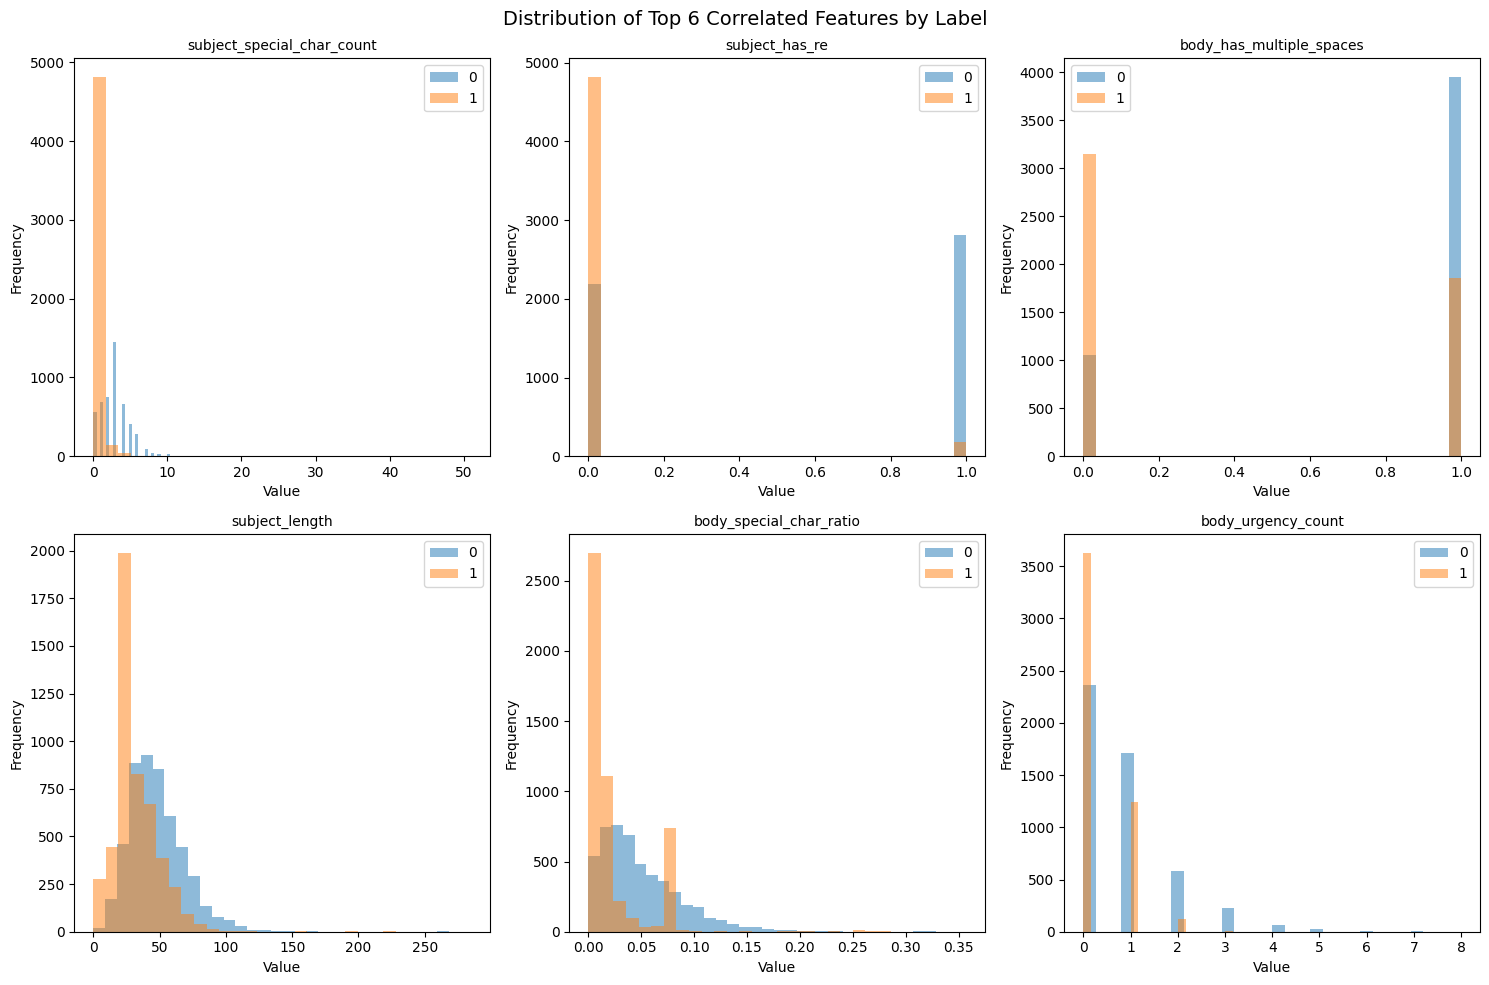

Plot saved as 'feature_distributions.png'


In [ ]:
top_6_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_6_features):
    ax = axes[idx]
    for label in df_features['label'].unique():
        data = df_features[df_features['label'] == label][feature]
        ax.hist(data, bins=30, alpha=0.5, label=str(label))
    ax.set_title(feature, fontsize=10)
    ax.legend()
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Top 6 Correlated Features by Label', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'feature_distributions.png'")


In [ ]:
# Save full feature dataset
df_features.to_csv('phishing_features_extracted.csv', index=False)
print("✓ Features saved to 'phishing_features_extracted.csv'")

# Save feature names
feature_names = X.columns.tolist()
pd.DataFrame({'feature_name': feature_names}).to_csv('feature_names.csv', index=False)
print("✓ Feature names saved to 'feature_names.csv'")

# Save correlation results
correlations.to_csv('feature_correlations.csv')
print("✓ Correlations saved to 'feature_correlations.csv'")

print(f"\nFinal dataset ready for ML:")
print(f"  - Shape: {df_features.shape}")
print(f"  - Features: {len(feature_names)}")
print(f"  - Labels: {df_features['label'].value_counts().to_dict()}")



✓ Features saved to 'phishing_features_extracted.csv'
✓ Feature names saved to 'feature_names.csv'
✓ Correlations saved to 'feature_correlations.csv'

Final dataset ready for ML:
  - Shape: (10000, 57)
  - Features: 56
  - Labels: {0: 5000, 1: 5000}


In [ ]:
print("Preview of extracted features:")
df_features.head(10)

Preview of extracted features:


,sender_has_name,sender_domain_length,sender_has_numbers,sender_has_suspicious_tld,sender_receiver_same_domain,sender_name_email_mismatch,multiple_receivers,sender_length,subject_length,subject_word_count,...,body_has_urgency,body_has_financial,body_has_threat,body_has_action,body_asks_personal_info,body_has_generic_greeting,body_has_personalized_greeting,body_has_multiple_spaces,body_missing_space_count,label
0,1,7,0,0,0,1,0,46,36,5,...,0,1,0,1,0,0,0,1,2,0
1,1,14,0,0,0,1,0,48,22,3,...,0,0,0,0,0,0,0,0,0,1
2,1,15,1,0,0,1,0,49,20,4,...,0,0,0,1,0,0,0,1,0,1
3,1,7,0,0,0,0,0,33,7,1,...,0,0,0,0,0,0,0,0,0,1
4,1,7,0,0,0,1,0,32,27,5,...,0,0,0,0,0,0,0,1,3,1
5,1,15,0,0,0,1,0,37,41,6,...,0,0,0,1,0,0,0,1,0,0
6,1,11,0,0,0,1,0,35,42,6,...,1,0,0,0,0,0,0,1,0,1
7,1,13,0,0,0,1,0,50,91,12,...,1,0,0,1,0,0,0,1,0,0
8,1,14,0,0,0,1,0,45,84,11,...,0,0,0,1,0,0,0,0,4,0
9,1,9,1,0,0,1,0,37,20,4,...,0,0,0,1,0,0,0,1,0,1


In [ ]:
from google.colab import files

# Download extracted features
files.download('phishing_features_extracted.csv')
print("✓ Downloaded: phishing_features_extracted.csv")

# Download feature names
files.download('feature_names.csv')
print("✓ Downloaded: feature_names.csv")

# Download correlations
files.download('feature_correlations.csv')
print("✓ Downloaded: feature_correlations.csv")

# Download plots
files.download('feature_correlations.png')
print("✓ Downloaded: feature_correlations.png")

files.download('feature_distributions.png')
print("✓ Downloaded: feature_distributions.png")

print("\n" + "="*40)
print("All files downloaded successfully!")
print("="*40)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: phishing_features_extracted.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloaded: feature_correlations.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: feature_distributions.png

All files downloaded successfully!
